In [20]:
#1. working with the Polynomial Regression model

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([258.00 , 270.00 , 294.00 , 320.00  , 342.0 , 368.0 , 396.0 , 446.0 , 480.0 , 586.0])\
 [:,np.newaxis]
y = np.array([236.4, 234.4, 252.8, 298.6, 314.2,
              342.2, 360.8, 368.0, 391.2, 390.8])

# 2. importing the Matplotlib
import matplotlib.pyplot as plt



In [21]:
lr = LinearRegression()
pr = LinearRegression()

quad = PolynomialFeatures(degree = 2)
X_quad = quad.fit_transform(X)  # 1. Fitting the X data on Polynomial degree = 2


In [22]:
# 1. Starting the LinearRegresison
X_fit = np.arange(250 , 600 , 10)[: , np.newaxis]

lr.fit(X, y)
pr.fit(X_quad , y)

# 2. Fiited both on Algorithm
y_lr_fit = lr.predict(X)
y_pr_fit = pr.predict(quad.fit_transform(X))  # first need to fit the data on poly degree

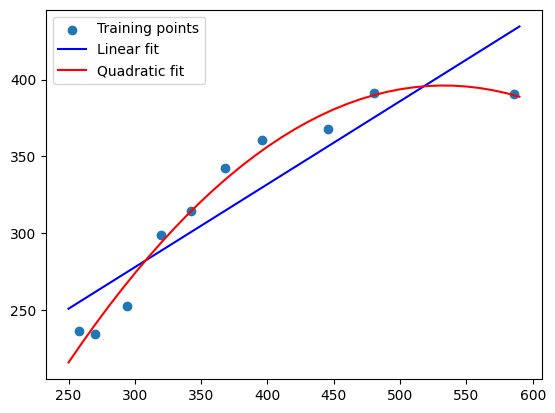

In [23]:
y_lr_pred = lr.predict(X_fit)
y_pr_pred = pr.predict(quad.fit_transform(X_fit))

plt.scatter(X , y, label='Training points')
plt.plot(X_fit , y_lr_pred , 'b' , label='Linear fit')
plt.plot(X_fit , y_pr_pred , 'r' , label='Quadratic fit')
plt.legend(loc='upper left')
plt.show()

In [24]:
# 1. MAE AND MSE
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

# 1. MSE
mse_lr = mean_squared_error(y , y_lr_fit)
mse_pr = mean_squared_error(y , y_pr_fit)

# 2. MAE
mae_lr = mean_absolute_error(y , y_lr_fit)
mae_pr = mean_absolute_error(y , y_pr_fit)

#3. r2_score
r2_lr = r2_score(y , y_lr_fit)
r2_pr = r2_score(y , y_pr_fit)

print(f"MSE Linear Regression : {mse_lr}")
print(f"MSE Polynomial Regression : {mse_pr}")
print(f"MAE Linear Regression : {mae_lr}")
print(f"MAE Polynomial Regression : {mae_pr}")
print(f"R2 Linear Regression : {r2_lr}")
print(f"R2 Polynomial Regression : {r2_pr}")


MSE Linear Regression : 569.7796663183207
MSE Polynomial Regression : 61.33021451744772
MAE Linear Regression : 21.898155760139353
MAE Polynomial Regression : 6.378821033863164
R2 Linear Regression : 0.8317053837891232
R2 Polynomial Regression : 0.9818850241163604


### Working with the Real Housing Data set

working with the Ames real housing data set from the fetch_openml

In [25]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name = 'house_prices' , as_frame = True)
df = ames.frame

# 1. Selecting the columns

columns = [
    "OverallQual",
    "OverallCond",
    "GrLivArea",
    "CentralAir",
    "TotalBsmtSF",
    "SalePrice",
]
df = df[columns]
df.head()

,OverallQual,OverallCond,GrLivArea,CentralAir,TotalBsmtSF,SalePrice
0,7,5,1710,Y,856,208500
1,6,8,1262,Y,1262,181500
2,7,5,1786,Y,920,223500
3,7,5,1717,Y,756,140000
4,8,5,2198,Y,1145,250000


In [26]:
df = df.copy() # 1. this is for the fix of settingWithCopyWarning

In [27]:
# 1. converting y / n in 0 and 1
df['CentralAir'] = df['CentralAir'].map({'N': 0, 'Y': 1})

In [28]:
df['CentralAir'].value_counts()


,count
CentralAir,
1,1365
0,95


## Modeling the Ames house

**Modeling the nonlinear - relationship**

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


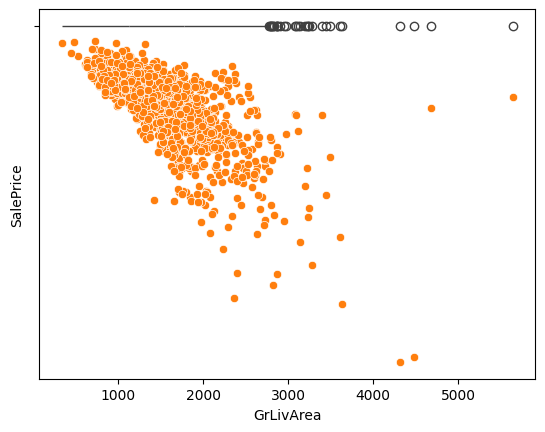

In [30]:
sns.boxplot(x = df['GrLivArea'] ,data = df)
sns.scatterplot(x = df['GrLivArea'] , y = df['SalePrice'], data = df)
plt.show()

# plt is clealry showing the the Data above 4000 can

In [31]:
X = df[['GrLivArea']].values
y = df['SalePrice'].values

# 1. the values above 4000 can be outlier and skew the best fit line

X = X[(df['GrLivArea'] < 4000)]
y = y[(df['GrLivArea'] < 4000)]

print(X.shape)
print(y.shape)

(1456, 1)
(1456,)


In [32]:
# 1. creating the polynomial fratures
from sklearn.preprocessing import PolynomialFeatures

quad = PolynomialFeatures(degree = 2)
X_quadratic = quad.fit_transform(X)

cubic = PolynomialFeatures(degree = 3)
X_cubic = cubic.fit_transform(X)

# 2. Creating a smooth line to draw a smooth reression line curve
X_fit = np.arange(X.min()-1 , X.max()+2 , 1)[:,np.newaxis]

# 3. creating the Regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

lr = LinearRegression()
lr.fit(X, y)
y_lin_fit = lr.predict(X_fit)
r2_score_lr = r2_score(y, lr.predict(X))
#4. Qud model
lr.fit(X_quadratic , y)
y_quad_fit = lr.predict(quad.fit_transform(X_fit))
r2_score_quad = r2_score(y , lr.predict(X_quadratic))
# 5. Cubic model
lr.fit(X_cubic , y)
y_cubic_fit = lr.predict(cubic.fit_transform(X_fit))
r2_score_cubic = r2_score(y , lr.predict(X_cubic))


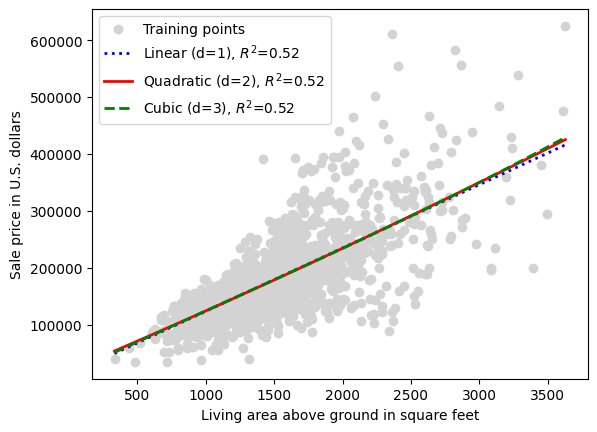

In [33]:
# Plot results
plt.scatter(X, y, label='Training points', color='lightgray')

plt.plot(
    X_fit,
    y_lin_fit,
    label=f'Linear (d=1), $R^2$={r2_score_lr:.2f}',
    color='blue',
    lw=2,
    linestyle=':'
)

plt.plot(
    X_fit,
    y_quad_fit,
    label=f'Quadratic (d=2), $R^2$={r2_score_quad:.2f}',
    color='red',
    lw=2,
    linestyle='-'
)

plt.plot(
    X_fit,
    y_cubic_fit,
    label=f'Cubic (d=3), $R^2$={r2_score_cubic:.2f}',
    color='green',
    lw=2,
    linestyle='--'
)

plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc='upper left')
plt.show()

###Using the Decision tree Regressor on the Ames housing dataset

In [36]:
from sklearn.tree import DecisionTreeRegressor

X = df[['GrLivArea']].values
y = df['SalePrice'].values

tree_depth_4 = DecisionTreeRegressor(max_depth = 4)
tree_depth_4.fit(X, y)

DecisionTreeRegressor(max_depth=4)

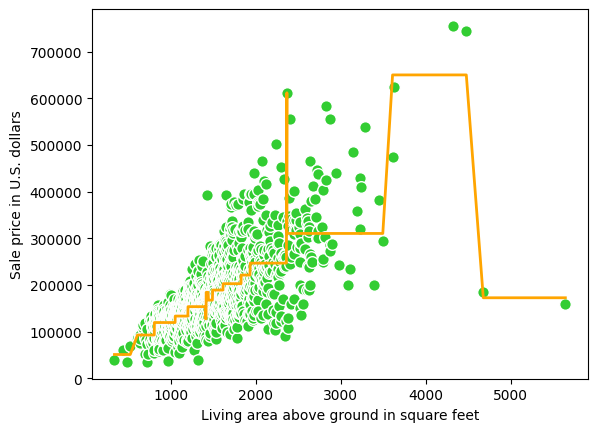

In [37]:
# 1. Creating the Regression plot

def lin_reg_plot(x , y , model):
  plt.scatter(x,y,c = 'limegreen', edgecolor= 'white', s=70)
  plt.plot(x , model.predict(x) , color = 'orange' , lw = 2)

sort_idx = X.flatten().argsort()

lin_reg_plot(X[sort_idx] , y[sort_idx] , tree_depth_4)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.show()